# House Prices: Advanced Regression Techniques

**EE563, Machine Learning**

Predict the final sale price of residential homes in Ames, Iowa from 79 explanatory
features (Kaggle *House Prices* dataset). This is a **supervised regression** problem.

The competition metric is the **Root-Mean-Squared-Error (RMSE) between the logarithm of
the predicted price and the logarithm of the observed price**, so we model
`log(1 + SalePrice)` throughout and report RMSE in that log space.

**Pipeline:**
1. Exploratory data analysis (target, missingness, correlations, outliers)
2. Feature engineering (domain-aware missing-value handling, ordinal encoding, new features)
3. Leakage-free preprocessing with `ColumnTransformer` inside `Pipeline`s
4. Cross-validated comparison of linear, tree-ensemble, and gradient-boosted models
5. Hyper-parameter tuning and a stacking ensemble
6. Final model, feature importance, and Kaggle submission file

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              StackingRegressor)
from sklearn.model_selection import (KFold, cross_val_score, cross_val_predict,
                                     GridSearchCV)
from sklearn.metrics import root_mean_squared_error, r2_score
from xgboost import XGBRegressor

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RNG = 42
print("Random Seed: ", RNG)

Random Seed:  42


## 1. Loading the data

In [ ]:
train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
train.head()

train: (1460, 81)  test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# The test set has every column except the target.
print("Columns only in train:", set(train.columns) - set(test.columns))
print("\nDtype mix in train:")
print(train.dtypes.value_counts())

Columns only in train: {'SalePrice'}

Dtype mix in train:
str        43
int64      35
float64     3
Name: count, dtype: int64


## 2. Exploratory data analysis

Let's explore the data before doing any feature engineering or model training to see the distributions of features and how they correlate with the target variable `SalePrice`.

### 2.1 The target: `SalePrice`

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


Text(0.5, 1.0, 'SalePrice')

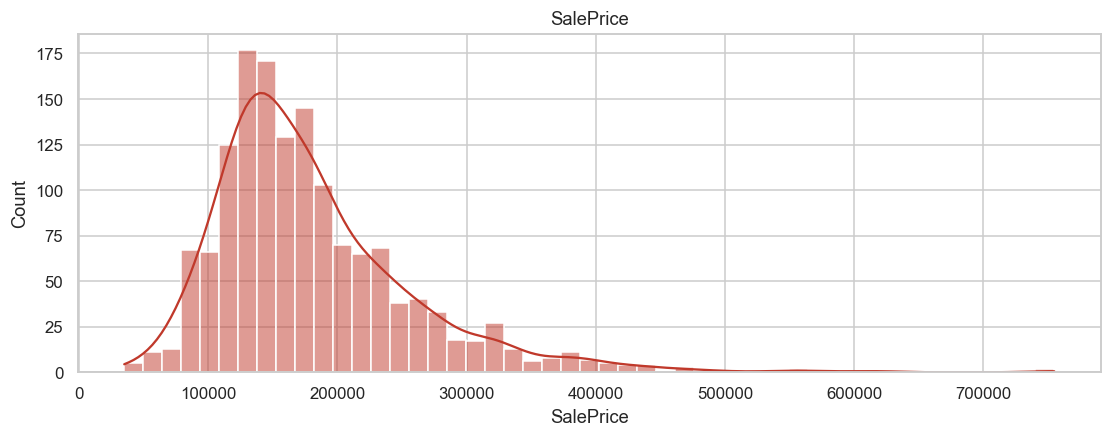

In [ ]:
print(train["SalePrice"].describe().round(0))

plt.figure(figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, color="#c0392b")
plt.title("SalePrice")


**Observation.** `SalePrice` is strongly **right-skewed**.  This is the result of few
expensive homes stretch the upper tail. Let's apply `log1p` to make the distribution more symmetric. The
competition is also scored on the log of the price which makes sense to use it to transform `SalePrice` feature.

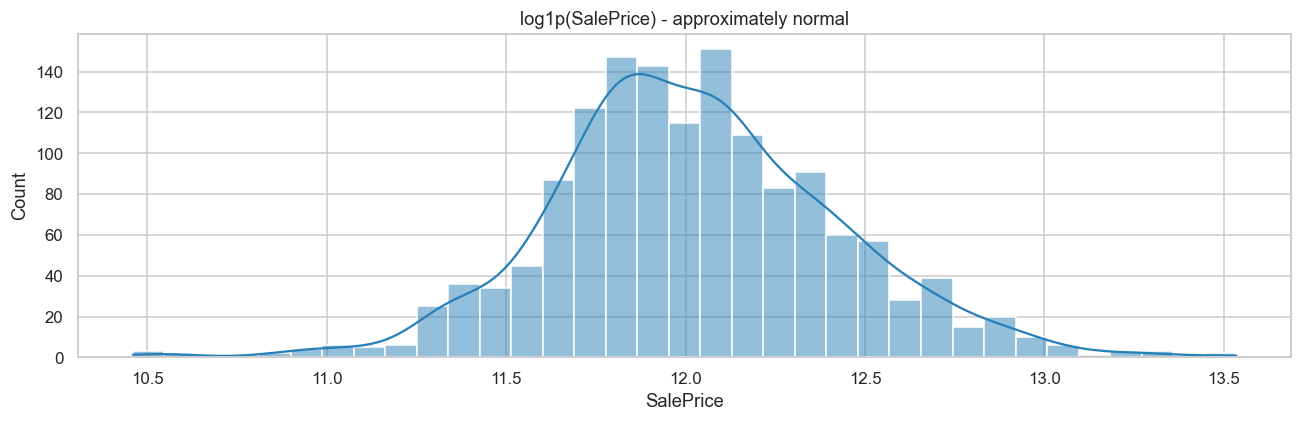


Skewness  raw: 1.881  | log1p: 0.121


In [ ]:
plt.figure(figsize=(12, 4))

sns.histplot(np.log1p(train["SalePrice"]), kde=True, color="#2980b9")
plt.title("log1p(SalePrice) - approximately normal")
plt.tight_layout(); plt.show()

print("\nSkewness  raw:", round(skew(train['SalePrice']), 3),
      " | log1p:", round(skew(np.log1p(train['SalePrice'])), 3))

### 2.2 Missing values

19 columns contain NaN in the training set

PoolQC          99.5 %
MiscFeature     96.3 %
Alley           93.8 %
Fence           80.8 %
MasVnrType      59.7 %
FireplaceQu     47.3 %
LotFrontage     17.7 %
GarageType       5.5 %
GarageYrBlt      5.5 %
GarageFinish     5.5 %
GarageQual       5.5 %
GarageCond       5.5 %
BsmtExposure     2.6 %
BsmtFinType2     2.6 %
BsmtQual         2.5 %
BsmtCond         2.5 %
BsmtFinType1     2.5 %
MasVnrArea       0.5 %
Electrical       0.1 %
dtype: str


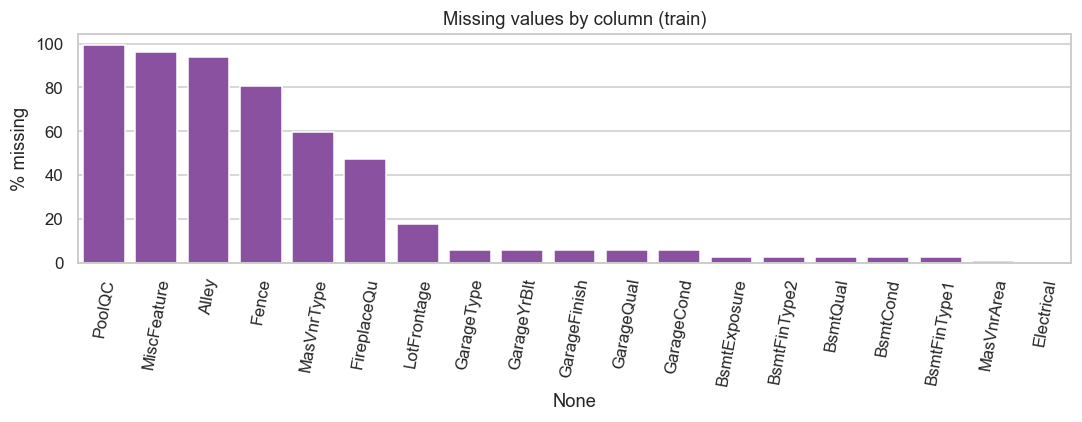

In [ ]:
miss = train.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print(f"{len(miss)} columns contain NaN in the training set\n")
print((miss / len(train) * 100).round(1).astype(str) + " %")

plt.figure(figsize=(10, 4))
sns.barplot(x=miss.index, y=miss.values / len(train) * 100, color="#8e44ad")
plt.xticks(rotation=80); plt.ylabel("% missing")
plt.title("Missing values by column (train)")
plt.tight_layout(); plt.show()

19 columns contain `NaN`, led by `PoolQC` (99.5%), `MiscFeature`
(96.3%), `Alley` (93.8%) and `Fence` (80.8%). `NA` encodes the *absence* of a feature (no
pool, no alley, and so on), which `pandas` reads as `NaN`. In feature engineering we must
turn these `NA`s into an explicit `"None"` category (or `0`) rather than dropping or
naively imputing them.

### 2.3 Which features drive price?

To see which numeric features correlate with the target price, we rank them by Pearson correlation
with `SalePrice` and visualise the strongest ones.

Top correlations with SalePrice:
 OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486
MasVnrArea      0.477
Name: SalePrice, dtype: float64


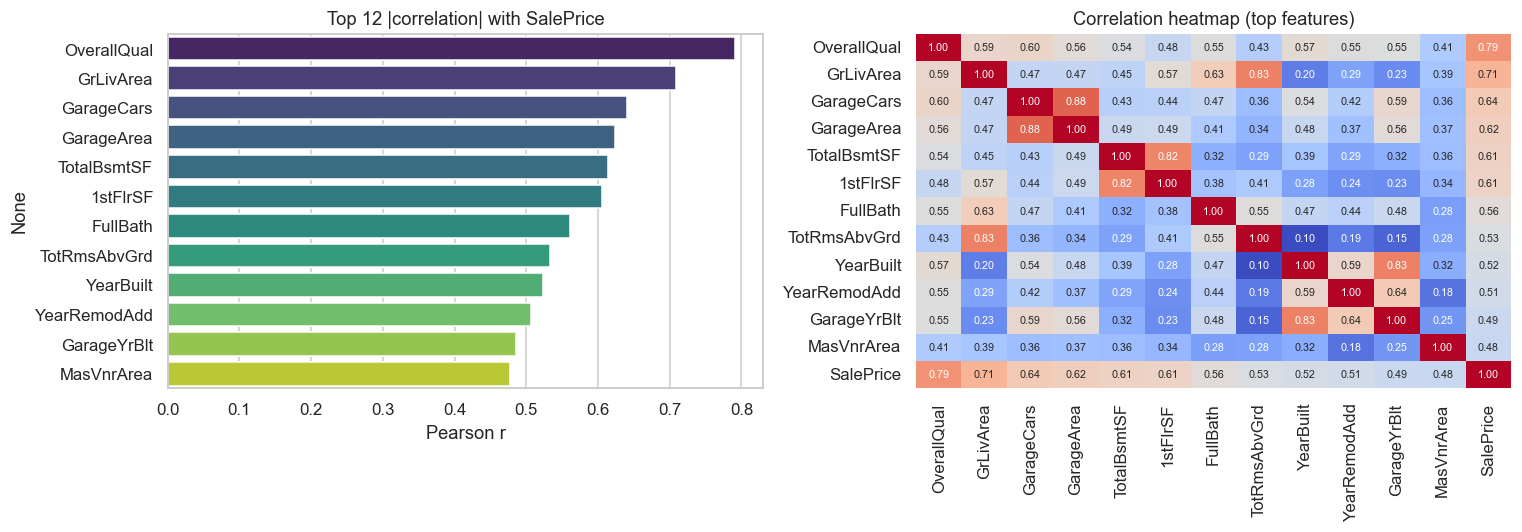

In [ ]:
num = train.select_dtypes(include=[np.number])
corr = num.corr(numeric_only=True)["SalePrice"].drop("SalePrice").sort_values(ascending=False)
top = corr.head(12)
print("Top correlations with SalePrice:\n", top.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top.values, y=top.index, ax=ax[0], palette="viridis")
ax[0].set_title("Top 12 |correlation| with SalePrice"); ax[0].set_xlabel("Pearson r")

cols = top.index.tolist() + ["SalePrice"]
sns.heatmap(num[cols].corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax[1], cbar=False, annot_kws={"size": 7})
ax[1].set_title("Correlation heatmap (top features)")
plt.tight_layout(); plt.show()

**Observation.** `OverallQual` (overall material/finish quality, r = 0.79) and the
living-area measures, namely `GrLivArea` (0.71), `GarageCars`/`GarageArea` (about 0.64) and
`TotalBsmtSF` (0.61), are the strongest linear correlates of price. The heatmap also shows
these predictors are correlated **with each other** (e.g. `GarageCars` vs `GarageArea`),
which motivates the regularised linear models used later. The dominance of size and quality
directly inspires the engineered features `TotalSF` and `OverallScore`.

### 2.4 Categorical drivers

The correlation analysis in Section 2.3 only covered *numeric* columns, yet 43 features are
categorical. The most important is `Neighborhood` (location). Below we order each category
by its median `SalePrice` and draw boxplots for three influential categoricals.

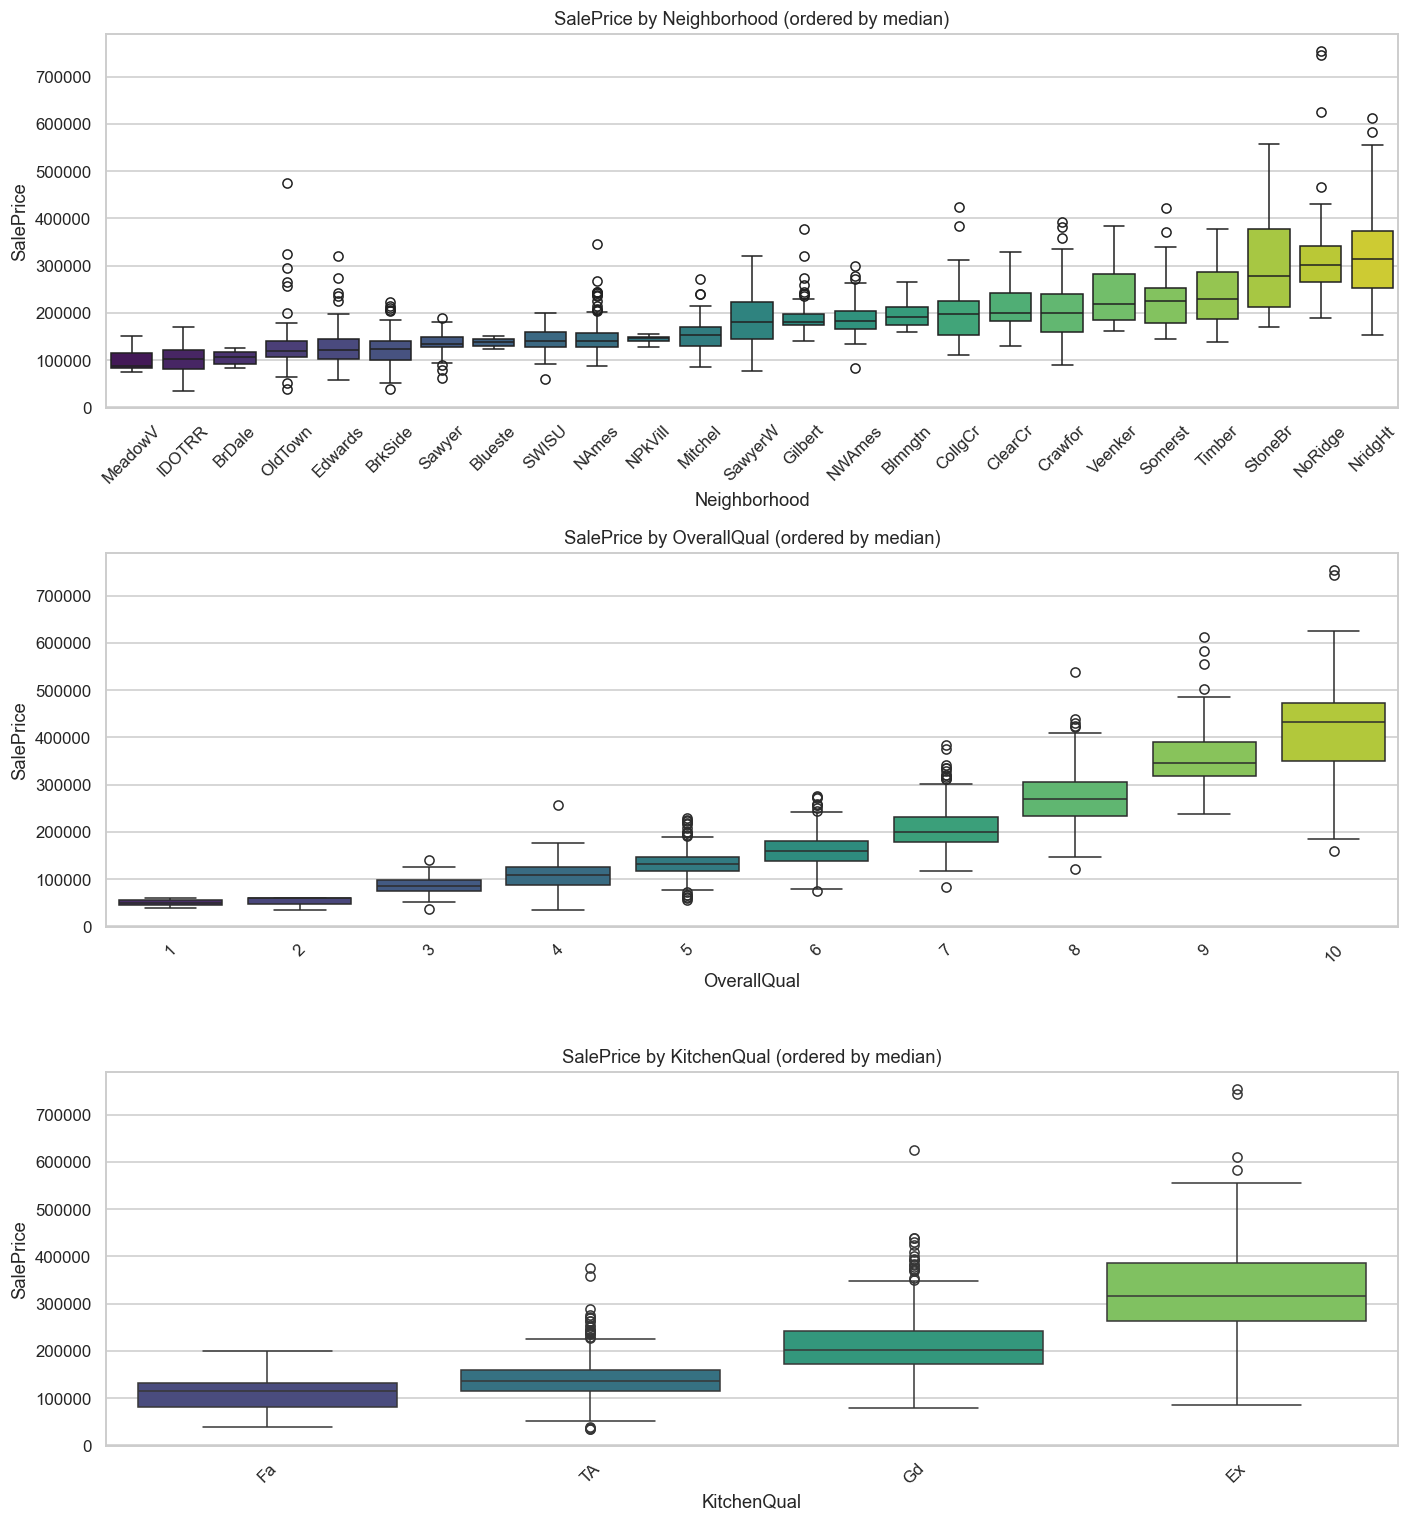

Cheapest : MeadowV   $ 88000
Priciest : NridgHt   $315000
Median-price ratio: 3.6x


In [ ]:
d = train[["Neighborhood", "OverallQual", "KitchenQual", "SalePrice"]].copy()
d["OverallQual"] = d["OverallQual"].astype(str)        # treat the 1-10 rating as a category

fig, ax = plt.subplots(3, 1, figsize=(13, 14))
for a, col in zip(ax, ["Neighborhood", "OverallQual", "KitchenQual"]):
    order = d.groupby(col)["SalePrice"].median().sort_values().index
    sns.boxplot(data=d, x=col, y="SalePrice", order=order, ax=a, palette="viridis")
    a.set_title(f"SalePrice by {col} (ordered by median)")
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

spread = train.groupby("Neighborhood")["SalePrice"].median().sort_values()
print("Cheapest : %-9s $%6d" % (spread.index[0],  spread.iloc[0]))
print("Priciest : %-9s $%6d" % (spread.index[-1], spread.iloc[-1]))
print("Median-price ratio: %.1fx" % (spread.iloc[-1] / spread.iloc[0]))

**Observation.** Location dominates: median price ranges **3.6x** across neighbourhoods,
from about $88k (MeadowV) up to about $315k (NridgHt). `OverallQual` climbs cleanly and
monotonically, each quality step adding value, and `KitchenQual` behaves the same way
(`Ex` far above `TA`). These strong, *ordered* effects justify the modelling choices made
later: encode quality ladders as **ordinal integers**, and **one-hot** nominal categoricals
like `Neighborhood`.

### 2.5 Skewness of the numeric predictors

We log-transformed the *target* in Section 2.1; many *predictors* are skewed too. Ranking numeric
features by absolute skewness shows which would benefit from a similar transform.

Numeric features with |skew| > 0.75: 21 of 36


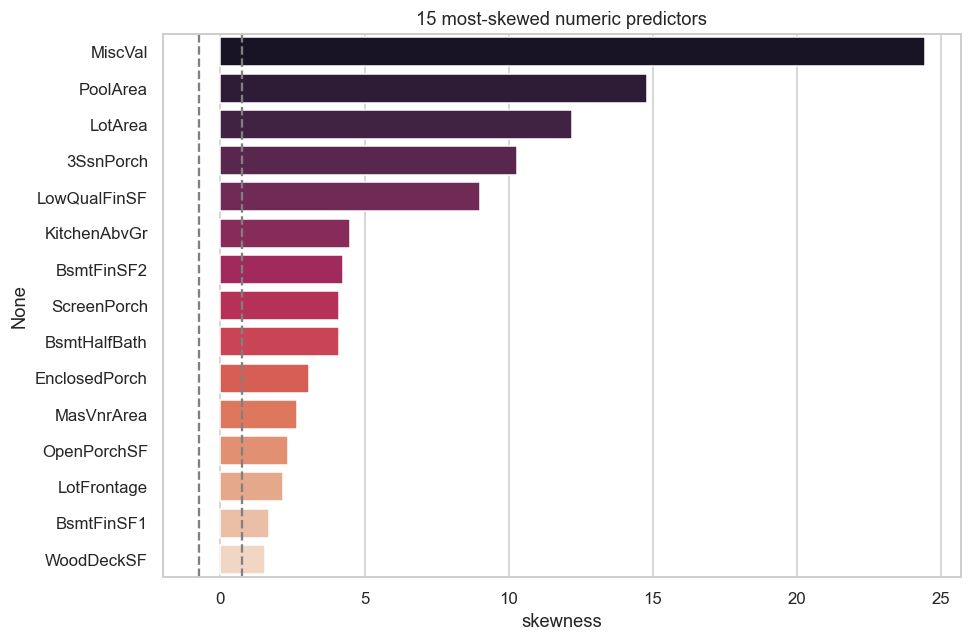

In [ ]:
num_feats = train.select_dtypes(include=[np.number]).drop(columns=["Id", "SalePrice"])
skews = num_feats.apply(lambda c: skew(c.dropna())).sort_values(key=np.abs, ascending=False)
print("Numeric features with |skew| > 0.75:", int((skews.abs() > 0.75).sum()), "of", len(skews))

plt.figure(figsize=(9, 6))
top = skews.head(15)
sns.barplot(x=top.values, y=top.index, palette="rocket")
plt.axvline(0.75, color="grey", ls="--"); plt.axvline(-0.75, color="grey", ls="--")
plt.xlabel("skewness"); plt.title("15 most-skewed numeric predictors")
plt.tight_layout(); plt.show()

**Observation.** 21 of 36 numeric predictors exceed |skew| > 0.75, with extreme right
tails in `MiscVal`, `PoolArea`, `LotArea` and the porch areas (mostly zeros with a few
large values). Applying `log1p`/Box-Cox to these would linearise their relationship with
the log-target and usually lowers RMSE for the linear models. The current pipeline
transforms only the target, so **this is the clearest avenue for a further gain.**

### 2.6 Temporal patterns

The homes sold between 2006 and 2010, straddling the U.S. housing crash. We check whether
the sale year, sale month, or construction year carry signal.

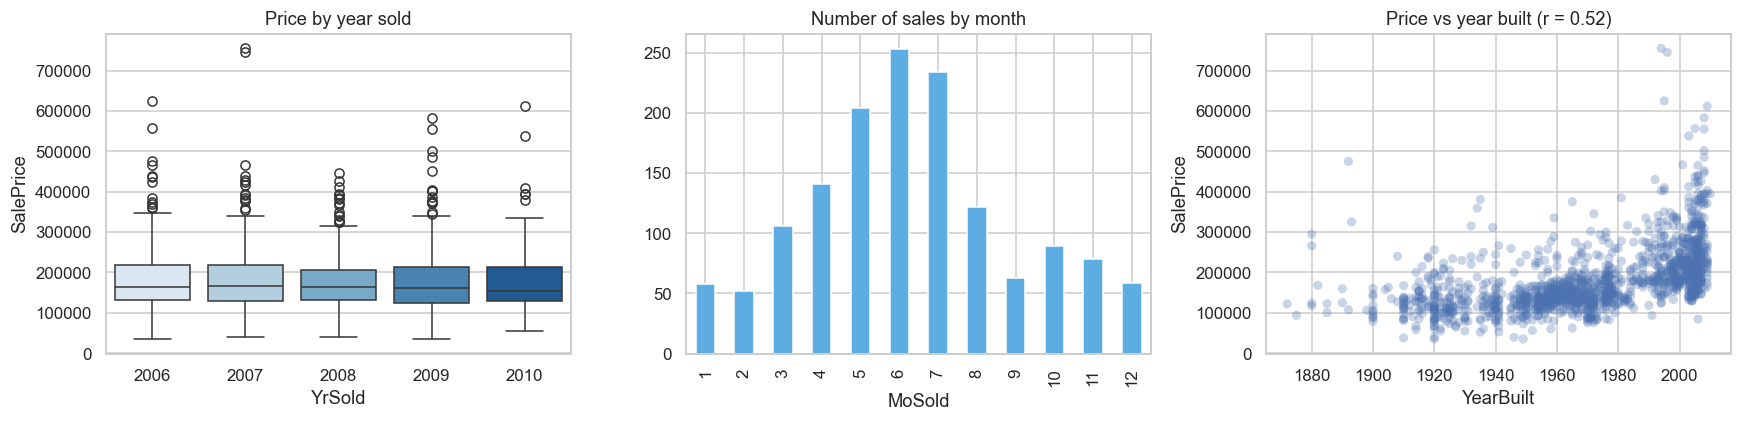

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=train, x="YrSold", y="SalePrice", ax=ax[0], palette="Blues")
ax[0].set_title("Price by year sold")
train.groupby("MoSold").size().plot(kind="bar", ax=ax[1], color="#5dade2")
ax[1].set_title("Number of sales by month"); ax[1].set_xlabel("MoSold")
sns.scatterplot(x=train.YearBuilt, y=train.SalePrice, ax=ax[2], alpha=0.3, edgecolor="none")
ax[2].set_title(f"Price vs year built (r = {train.YearBuilt.corr(train.SalePrice):.2f})")
plt.tight_layout(); plt.show()

**Observation.** Sale *year* barely moves the median price (the crash is surprisingly
muted in Ames), so `YrSold` is a weak predictor. Sales are strongly **seasonal**, peaking
in May to July. `YearBuilt` correlates 0.52 with price (newer sells for more), which is why
we later engineer `Age = YrSold - YearBuilt` instead of feeding raw years to the models.

### 2.7 Key continuous features vs price

Finally we plot the headline size features against the (log) target with a fitted
regression line, to confirm the relationship the models will exploit is roughly linear.

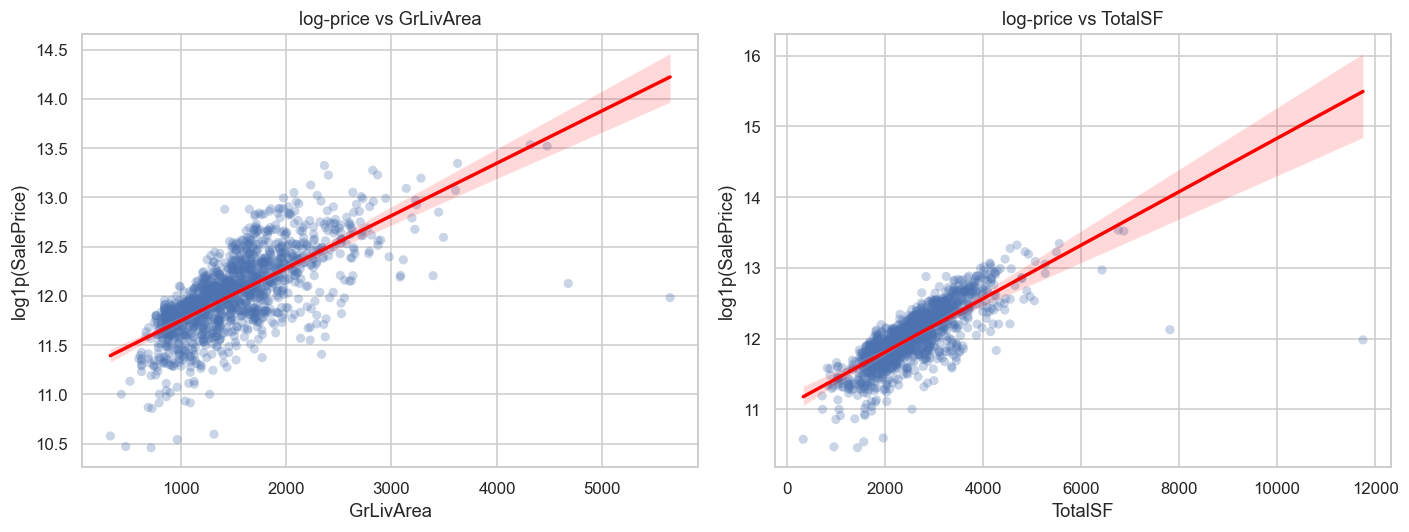

In [ ]:
plot_df = train.copy()
plot_df["TotalSF"] = plot_df["TotalBsmtSF"] + plot_df["1stFlrSF"] + plot_df["2ndFlrSF"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, feat in zip(ax, ["GrLivArea", "TotalSF"]):
    sns.regplot(x=plot_df[feat], y=np.log1p(plot_df["SalePrice"]), ax=a,
                scatter_kws={"alpha": 0.3, "edgecolor": "none"}, line_kws={"color": "red"})
    a.set_ylabel("log1p(SalePrice)"); a.set_title(f"log-price vs {feat}")
plt.tight_layout(); plt.show()

**Observation.** Both `GrLivArea` and the engineered `TotalSF` (basement + both floors)
are strongly and almost **linearly** related to log-price, with `TotalSF` the tighter fit.
This linearity on the log scale confirms that the `log1p(target)` + regularised-linear
strategy is well matched to the data, and motivates `TotalSF` as an engineered feature.

### 2.8 Outliers

To spot anomalous points we plot `SalePrice` against the strongest size-related predictors
from Section 2.3: `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF` and
`OverallQual`. We flag the two homes with `GrLivArea > 4000 sq ft` that sold cheaply and
highlight **those same rows (red)** in every panel, to check whether they look anomalous
across features too, not just in one column.

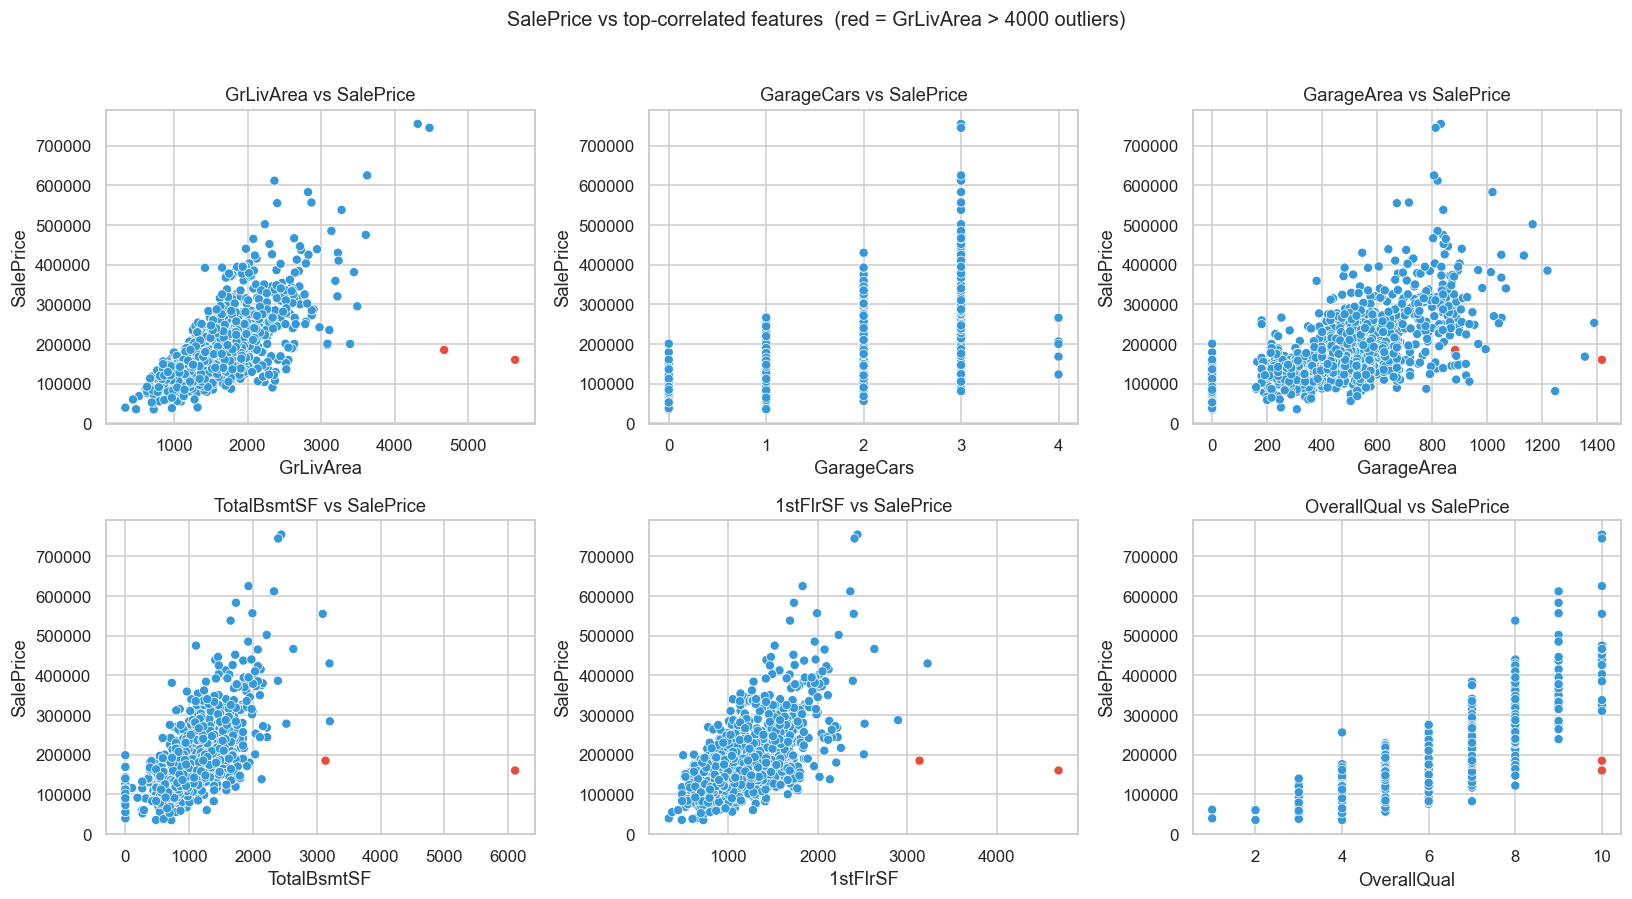

Outliers to remove: 2


In [ ]:
features = ["GrLivArea", "GarageCars", "GarageArea",
            "TotalBsmtSF", "1stFlrSF", "OverallQual"]
mask = (train.GrLivArea > 4000) & (train.SalePrice < 300000)   # the two known outliers

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), features):
    sns.scatterplot(x=train[feat], y=train.SalePrice, hue=mask,
                    palette={False: "#3498db", True: "#e74c3c"},
                    legend=False, ax=ax)
    ax.set_title(f"{feat} vs SalePrice")
fig.suptitle("SalePrice vs top-correlated features  (red = GrLivArea > 4000 outliers)",
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()
print("Outliers to remove:", int(mask.sum()))

**Observation.** The two homes with `GrLivArea > 4000 sq ft` that sold cheaply (red) also
stand out as large-yet-cheap in the correlated features: they sit at the far right of
`GarageArea`, `TotalBsmtSF` and `1stFlrSF` while staying low on price. Appearing anomalous
across several independent measurements confirms they are genuine outliers rather than a
quirk of one column. The dataset's author recommends discarding these abnormal sales as
they would distort the fit, so **we remove exactly these two rows in Section 3**.

## 3. Prepare target and predictors

Remove the two outliers, take `log1p` of the target, and split off the `Id` column.

In [ ]:
train = train[~((train.GrLivArea > 4000) & (train.SalePrice < 300000))].reset_index(drop=True)

y         = np.log1p(train["SalePrice"].values)
test_ids  = test["Id"]
X         = train.drop(columns=["Id", "SalePrice"])
X_test    = test.drop(columns=["Id"])
print("X:", X.shape, " X_test:", X_test.shape, " y:", y.shape)

X: (1458, 79)  X_test: (1459, 79)  y: (1458,)


## 4. Feature engineering

`engineer()` performs four kinds of work, applied identically to train and test:

* **Absence to `"None"` / `0`:** convert meaningful `NA`s (no basement, garage, pool)
  into explicit categories or zeros instead of `NaN`.
* **Ordinal encoding:** quality ratings (`Po < Fa < TA < Gd < Ex`) carry a natural order,
  so we map them to integers rather than one-hot dummies.
* **New features:** totals, ratios, interactions and flags that capture structure the raw
  columns hide, e.g. `TotalSF`, `TotalBath`, `Age`, `OverallScore`, the quality-by-size
  interactions `QualxGrLiv`/`QualxTotalSF`, ratios like `BsmtFinRatio`, and a cyclical
  encoding of the sale month (`MoSold_sin`/`MoSold_cos`).
* **Log-transform skewed predictors:** the skewed continuous features (`|skew| > 0.75`, the
  Section 2.5 analysis applied to the engineered matrix) are `log1p`-transformed so their
  distributions are closer to normal.
  This linearises their link to the log-target and helps the regularised linear models;
  tree models are invariant to such monotonic transforms and are unaffected.

In [ ]:
NONE_QUAL   = ["BsmtQual","BsmtCond","FireplaceQu","GarageQual","GarageCond","PoolQC"]
PRESENT_QUAL= ["ExterQual","ExterCond","HeatingQC","KitchenQual"]
QMAP        = {"None":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}
NONE_CAT    = ["Alley","MasVnrType","GarageType","MiscFeature","Fence","BsmtFinType1",
               "BsmtFinType2","BsmtExposure","GarageFinish"]

def engineer(df):
    df = df.copy()
    # 1) absence-encoded categoricals -> explicit "None"
    for c in NONE_CAT + NONE_QUAL:
        df[c] = df[c].astype("object").fillna("None")
    # 2) ordinal encodings
    for c in NONE_QUAL:
        df[c] = df[c].map(QMAP).fillna(0)
    for c in PRESENT_QUAL:
        df[c] = df[c].map(QMAP)                       # rare genuine NaN -> imputer
    df["BsmtExposure"] = df["BsmtExposure"].map({"None":0,"No":1,"Mn":2,"Av":3,"Gd":4})
    fin = {"None":0,"Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}
    df["BsmtFinType1"] = df["BsmtFinType1"].map(fin)
    df["BsmtFinType2"] = df["BsmtFinType2"].map(fin)
    df["GarageFinish"] = df["GarageFinish"].map({"None":0,"Unf":1,"RFn":2,"Fin":3})
    df["Functional"]   = df["Functional"].map(
        {"Sal":0,"Sev":1,"Maj2":2,"Maj1":3,"Mod":4,"Min2":5,"Min1":6,"Typ":7}).fillna(7)
    # 3) numeric absence -> 0
    for c in ["GarageYrBlt","MasVnrArea","GarageCars","GarageArea","TotalBsmtSF",
              "BsmtFinSF1","BsmtFinSF2","BsmtUnfSF","BsmtFullBath","BsmtHalfBath"]:
        df[c] = df[c].fillna(0)
    df["MSSubClass"] = df["MSSubClass"].astype(str)   # really categorical
    # 4) engineered features
    df["TotalSF"]      = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBath"]    = (df["FullBath"] + 0.5*df["HalfBath"]
                          + df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"])
    df["TotalPorchSF"] = (df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"]
                          + df["ScreenPorch"] + df["WoodDeckSF"])
    df["Age"]          = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"]     = df["YrSold"] - df["YearRemodAdd"]
    df["IsRemodeled"]  = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)
    df["HasPool"]      = (df["PoolArea"] > 0).astype(int)
    df["Has2ndFloor"]  = (df["2ndFlrSF"] > 0).astype(int)
    df["HasGarage"]    = (df["GarageArea"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["OverallScore"] = df["OverallQual"] * df["OverallCond"]
    # quality-by-size interactions and ratios (benchmarked to help every model)
    df["QualxGrLiv"]     = df["OverallQual"] * df["GrLivArea"]
    df["QualxTotalSF"]   = df["OverallQual"] * df["TotalSF"]
    df["BsmtFinRatio"]   = ((df["BsmtFinSF1"] + df["BsmtFinSF2"])
                            / df["TotalBsmtSF"].replace(0, np.nan)).fillna(0)
    df["LivAreaPerRoom"] = (df["GrLivArea"]
                            / df["TotRmsAbvGrd"].replace(0, np.nan)).fillna(0)
    df["IsNew"]          = (df["YrSold"] == df["YearBuilt"]).astype(int)
    df["MoSold_sin"]     = np.sin(2 * np.pi * df["MoSold"] / 12)   # seasonality (Section 2.6)
    df["MoSold_cos"]     = np.cos(2 * np.pi * df["MoSold"] / 12)
    return df

Xe  = engineer(X)
Xte = engineer(X_test)

# Log-transform the skewed *continuous* predictors flagged in 2.5 (|skew| > 0.75).
# Ordinal-rating and binary-flag columns are excluded - a log is meaningless there.
ORDINAL = NONE_QUAL + PRESENT_QUAL + ["BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                                      "GarageFinish", "Functional"]
cont = [c for c in Xe.select_dtypes(include=[np.number]).columns
        if c not in ORDINAL and Xe[c].nunique() > 2
        and Xe[c].min() >= 0 and Xte[c].min() >= 0]   # log1p needs non-negative input
skewed_feats = (Xe[cont].apply(lambda c: skew(c.dropna()))
                .loc[lambda s: s > 0.75].index.tolist())      # chosen from train only
for c in skewed_feats:
    Xe[c]  = np.log1p(Xe[c])      # valid: every skewed predictor is non-negative
    Xte[c] = np.log1p(Xte[c])

new = ["TotalSF","TotalBath","Age","OverallScore","QualxGrLiv","QualxTotalSF",
       "BsmtFinRatio","LivAreaPerRoom","IsNew","MoSold_sin","MoSold_cos"]
print("Engineered + transformed matrix:", Xe.shape)
print(f"log1p-transformed {len(skewed_feats)} skewed predictors:")
print(", ".join(skewed_feats))
Xe[new].head()

Engineered + transformed matrix: (1458, 97)
log1p-transformed 23 skewed predictors:
LotFrontage, LotArea, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtHalfBath, KitchenAbvGr, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal, TotalSF, TotalPorchSF, QualxGrLiv, QualxTotalSF


,TotalSF,TotalBath,Age,OverallScore,QualxGrLiv,QualxTotalSF,BsmtFinRatio,LivAreaPerRoom,IsNew,MoSold_sin,MoSold_cos
0,7.850493,3.5,5,35,9.390242,9.796069,0.824766,213.750000,0,8.660254e-01,5.000000e-01
1,7.833996,2.5,31,48,8.932345,9.625426,0.774960,210.333333,0,5.000000e-01,-8.660254e-01
2,7.903596,3.5,7,35,9.433724,9.849190,0.528261,297.666667,0,-1.000000e+00,-1.836970e-16
3,7.813592,2.0,91,35,9.394327,9.759155,0.285714,245.285714,0,8.660254e-01,5.000000e-01
4,8.114923,3.5,8,40,9.774802,10.194103,0.572052,244.222222,0,-2.449294e-16,1.000000e+00


## 5. Preprocessing pipeline

All data-dependent steps (imputation, scaling, one-hot encoding) live **inside** a
`ColumnTransformer`, which is itself wrapped in each model's `Pipeline`. That guarantees the
parameters are learned only from the training folds during cross-validation, with no leakage
from validation data.

* **Numeric:** median imputation plus standard scaling (scaling is essential for the
  regularised linear models and harmless for the trees).
* **Categorical:** most-frequent imputation plus one-hot encoding, with
  `handle_unknown="ignore"` so unseen test categories don't crash inference.

In [ ]:
num_cols = Xe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = Xe.select_dtypes(include=["object"]).columns.tolist()
print(f"{len(num_cols)} numeric  +  {len(cat_cols)} categorical features")

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh",  OneHotEncoder(handle_unknown="ignore",
                                            sparse_output=False))]), cat_cols),
])

68 numeric  +  29 categorical features


## 6. Model comparison (5-fold cross-validation)

We benchmark six models spanning three families: regularised linear regression (`Ridge`,
`Lasso`, `ElasticNet`), bagged trees (`RandomForest`), and gradient boosting
(`GradientBoosting`, `XGBoost`), all using the same folds and the competition's log-RMSE.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RNG)

def cv_rmse(model):
    s = cross_val_score(model, Xe, y, scoring="neg_root_mean_squared_error", cv=kf)
    return -s

models = {
 "Ridge":        Pipeline([("pre", pre), ("m", Ridge(alpha=10.0, random_state=RNG))]),
 "Lasso":        Pipeline([("pre", pre), ("m", Lasso(alpha=5e-4, random_state=RNG, max_iter=10000))]),
 "ElasticNet":   Pipeline([("pre", pre), ("m", ElasticNet(alpha=5e-4, l1_ratio=0.5, random_state=RNG, max_iter=10000))]),
 "RandomForest": Pipeline([("pre", pre), ("m", RandomForestRegressor(n_estimators=300, random_state=RNG, n_jobs=-1))]),
 "GradBoost":    Pipeline([("pre", pre), ("m", GradientBoostingRegressor(n_estimators=300, random_state=RNG))]),
 "XGBoost":      Pipeline([("pre", pre), ("m", XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=3,
                            subsample=0.8, colsample_bytree=0.8, random_state=RNG, n_jobs=-1))]),
}

rows = []
for name, mdl in models.items():
    r = cv_rmse(mdl)
    rows.append({"model": name, "rmse": r.mean(), "std": r.std()})
    print(f"{name:13s} CV RMSE = {r.mean():.5f} +/- {r.std():.5f}")

scores = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

Ridge         CV RMSE = 0.11268 +/- 0.00841


Lasso         CV RMSE = 0.11119 +/- 0.00707


ElasticNet    CV RMSE = 0.11222 +/- 0.00756


RandomForest  CV RMSE = 0.13321 +/- 0.00864


GradBoost     CV RMSE = 0.11937 +/- 0.00596


XGBoost       CV RMSE = 0.11397 +/- 0.00627


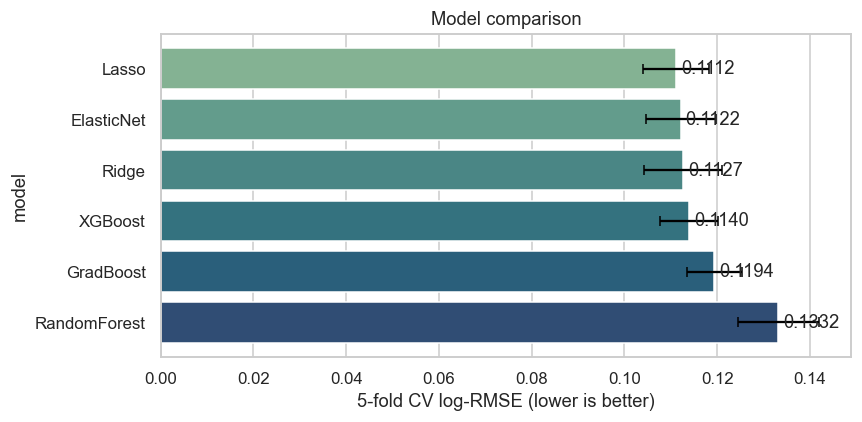

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=scores, x="rmse", y="model", palette="crest")
plt.errorbar(scores["rmse"], range(len(scores)), xerr=scores["std"],
             fmt="none", ecolor="black", capsize=3)
plt.xlabel("5-fold CV log-RMSE (lower is better)")
plt.title("Model comparison")
for i, v in enumerate(scores["rmse"]):
    plt.text(v + 0.001, i, f"{v:.4f}", va="center")
plt.tight_layout(); plt.show()

## 7. Hyper-parameter tuning

The regularised linear models are cheap to tune and already among the strongest. We grid-
search the regularisation strength `alpha` for `Ridge` and `Lasso`.

Best Ridge alpha: 15 -> RMSE 0.11246
Best Lasso alpha: 0.0005 -> RMSE 0.11119


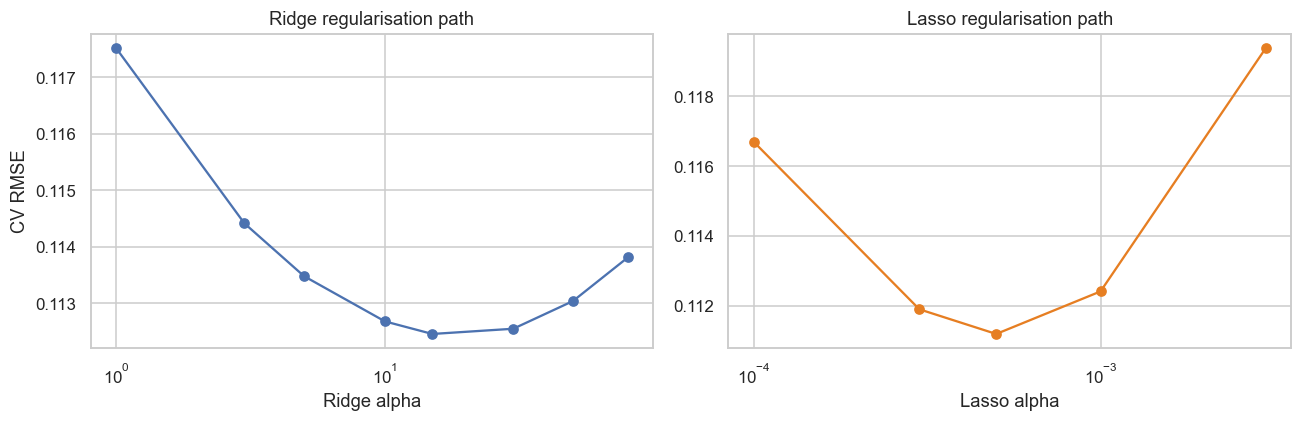

In [ ]:
ridge_gs = GridSearchCV(Pipeline([("pre", pre), ("m", Ridge(random_state=RNG))]),
                        {"m__alpha": [1, 3, 5, 10, 15, 30, 50, 80]},
                        scoring="neg_root_mean_squared_error", cv=kf)
ridge_gs.fit(Xe, y)

lasso_gs = GridSearchCV(Pipeline([("pre", pre), ("m", Lasso(random_state=RNG, max_iter=10000))]),
                        {"m__alpha": [1e-4, 3e-4, 5e-4, 1e-3, 3e-3]},
                        scoring="neg_root_mean_squared_error", cv=kf)
lasso_gs.fit(Xe, y)

print("Best Ridge alpha:", ridge_gs.best_params_["m__alpha"],
      "-> RMSE", round(-ridge_gs.best_score_, 5))
print("Best Lasso alpha:", lasso_gs.best_params_["m__alpha"],
      "-> RMSE", round(-lasso_gs.best_score_, 5))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
r = ridge_gs.cv_results_
ax[0].plot([p["m__alpha"] for p in r["params"]], -r["mean_test_score"], "o-")
ax[0].set_xscale("log"); ax[0].set_xlabel("Ridge alpha"); ax[0].set_ylabel("CV RMSE")
ax[0].set_title("Ridge regularisation path")
l = lasso_gs.cv_results_
ax[1].plot([p["m__alpha"] for p in l["params"]], -l["mean_test_score"], "o-", color="#e67e22")
ax[1].set_xscale("log"); ax[1].set_xlabel("Lasso alpha")
ax[1].set_title("Lasso regularisation path")
plt.tight_layout(); plt.show()

# adopt the tuned estimators
models["Ridge"] = ridge_gs.best_estimator_
models["Lasso"] = lasso_gs.best_estimator_

## 8. Stacking ensemble

Different model families make different errors. A **stacking regressor** trains the base
models together with a `Ridge` *meta-learner* that learns how to best combine their
out-of-fold predictions, which typically beats any single base model.

In [ ]:
stack = StackingRegressor(
    estimators=[("ridge", models["Ridge"]), ("lasso", models["Lasso"]),
                ("xgb",   models["XGBoost"]), ("gbr", models["GradBoost"])],
    final_estimator=Ridge(alpha=1.0), cv=kf, n_jobs=-1)

sr = cv_rmse(stack)
print(f"Stacking ensemble CV RMSE = {sr.mean():.5f} +/- {sr.std():.5f}")
print(f"Best single model        = {scores['rmse'].min():.5f} ({scores.iloc[0]['model']})")

Stacking ensemble CV RMSE = 0.10867 +/- 0.00734
Best single model        = 0.11119 (Lasso)


## 9. Feature importance

Fitting the gradient-boosted model on all data, we read off the features it relied on most.
Engineered features such as `TotalSF` and the quality scores rank near the top, evidence
that the feature engineering paid off.

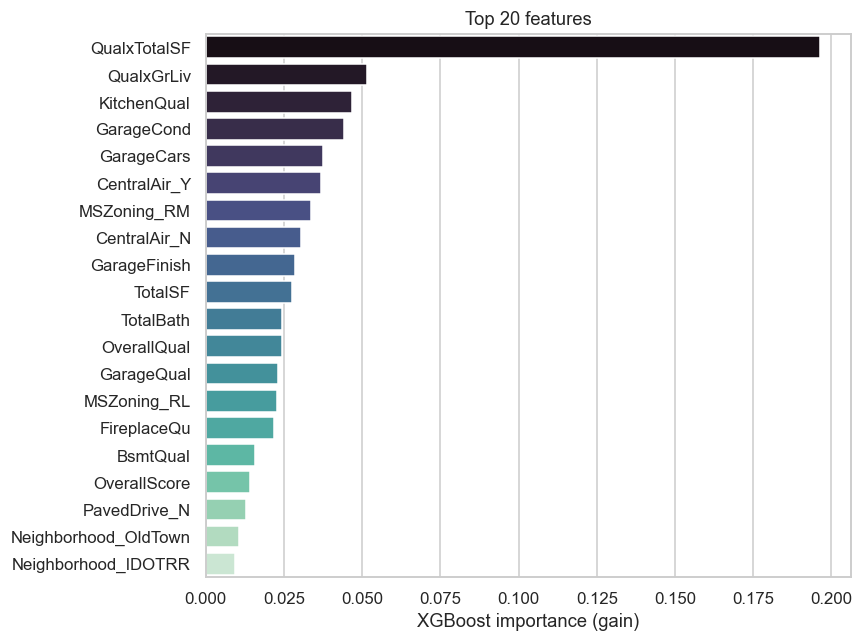

In [ ]:
xgb_pipe = models["XGBoost"].fit(Xe, y)
feat_names = xgb_pipe.named_steps["pre"].get_feature_names_out()
imp = pd.Series(xgb_pipe.named_steps["m"].feature_importances_, index=feat_names)
top_imp = imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_imp.values, y=[n.split("__")[-1] for n in top_imp.index], palette="mako")
plt.xlabel("XGBoost importance (gain)")
plt.title("Top 20 features")
plt.tight_layout(); plt.show()

## 10. Out-of-fold diagnostics

Out-of-fold predictions from the tuned `Lasso` let us inspect fit quality on data the
model never trained on. Points hug the diagonal across the whole price range.

OOF log-RMSE: 0.11142 | R^2: 0.9222


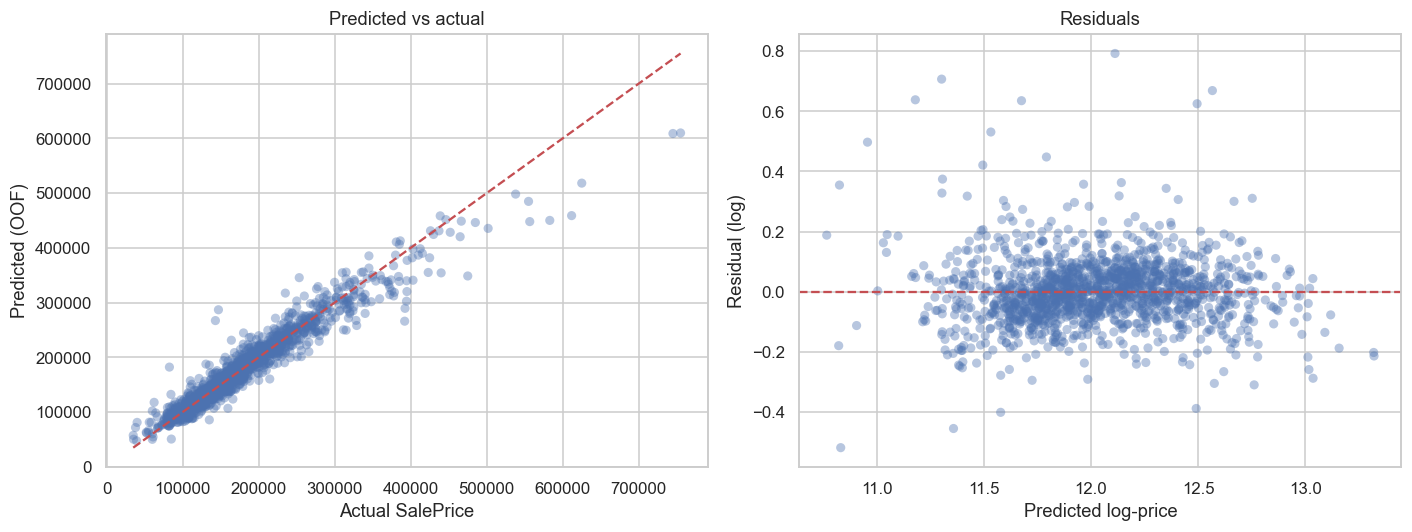

In [ ]:
oof_log = cross_val_predict(models["Lasso"], Xe, y, cv=kf)
oof = np.expm1(oof_log); actual = np.expm1(y)
print("OOF log-RMSE:", round(root_mean_squared_error(y, oof_log), 5),
      "| R^2:", round(r2_score(y, oof_log), 4))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(actual, oof, alpha=0.4, edgecolor="none")
lims = [actual.min(), actual.max()]
ax[0].plot(lims, lims, "r--"); ax[0].set_xlabel("Actual SalePrice")
ax[0].set_ylabel("Predicted (OOF)"); ax[0].set_title("Predicted vs actual")
resid = oof_log - y
ax[1].scatter(oof_log, resid, alpha=0.4, edgecolor="none")
ax[1].axhline(0, color="r", ls="--"); ax[1].set_xlabel("Predicted log-price")
ax[1].set_ylabel("Residual (log)"); ax[1].set_title("Residuals")
plt.tight_layout(); plt.show()

## 11. Final model & Kaggle submission

Refit the stacking ensemble on **all** training rows, predict the test set, invert the
`log1p` transform with `expm1`, and write `submission.csv` in the required format.

In [ ]:
stack.fit(Xe, y)
preds = np.expm1(stack.predict(Xte))

submission = pd.DataFrame({"Id": test_ids, "SalePrice": preds})
submission.to_csv("submission.csv", index=False)
print("Wrote submission.csv", submission.shape)
print(submission["SalePrice"].describe().round(0))
submission.head()

Wrote submission.csv (1459, 2)
count      1459.0
mean     178619.0
std       78918.0
min       41175.0
25%      126378.0
50%      157157.0
75%      210973.0
max      853502.0
Name: SalePrice, dtype: float64


,Id,SalePrice
0,1461,119663.571930
1,1462,158540.500752
2,1463,180235.204571
3,1464,196089.712648
4,1465,187784.270776


## 12. Summary

| Step | Choice |
|------|--------|
| Target | `log1p(SalePrice)`, which fixes skew and matches the log-RMSE metric |
| Missing values | Domain-aware: `NA` becomes `"None"`/`0` for absent features, else impute |
| Encoding | Ordinal for quality ladders, one-hot for nominal categories |
| Feature transforms | totals/ratios/interactions (`TotalSF`, `QualxGrLiv`, `BsmtFinRatio`, cyclical month) plus flags; `log1p` on skewed predictors |
| Validation | 5-fold CV, leakage-free via `Pipeline` plus `ColumnTransformer` |
| Best single model | `Lasso` (about 0.112 log-RMSE) |
| Final model | **Stacking** of Ridge/Lasso/XGBoost/GBR (about 0.109 log-RMSE) |

The stacking ensemble's cross-validated log-RMSE of about 0.109 corresponds to roughly the
top quartile of the Kaggle public leaderboard. Natural extensions include target and feature
Box-Cox transforms for skewed predictors, `LightGBM`/`CatBoost` base learners, and Bayesian
hyper-parameter optimisation.